## Introduction to document loading and chunking
concepts of document loading and chunking in the context of RAG and why they are important.


In [17]:
!pip install -q matplotlib

In [2]:
%%markdown
# Document Loading and Chunking for RAG

**Retrieval Augmented Generation (RAG)** is a natural language processing framework that combines the power of large language models (LLMs) with external knowledge retrieval. Instead of solely relying on the information embedded within their training data, RAG systems retrieve relevant information from a separate knowledge base and use this retrieved information to inform the generation of responses. This allows RAG models to provide more accurate, up-to-date, and contextually relevant answers, especially for domain-specific queries or questions about recent events not covered in the LLM's training data.

Within a RAG pipeline, **document loading** and **chunking** are fundamental and crucial initial steps.

**Document Loading** is the process of ingesting raw data from various sources (like text files, PDFs, HTML pages, databases, etc.) and converting it into a format that can be easily processed by the RAG system, typically into a structured representation like a list of documents or texts. This step is essential because the knowledge base used for retrieval needs to be populated with the relevant information in a usable format. Without effective document loading, the RAG system would have no external knowledge to retrieve from.

**Chunking** refers to the process of splitting large documents into smaller, manageable pieces called "chunks." LLMs and retrieval systems often have limitations on the amount of text they can process at once. Large documents need to be broken down so that individual chunks can be effectively embedded, indexed, and retrieved. The size and strategy of chunking significantly impact the retrieval performance. If chunks are too large, they might contain irrelevant information that dilutes the relevant parts. If they are too small, important context might be lost across chunk boundaries.

The effectiveness of **document loading** and **chunking** directly impacts the performance and relevance of the generated responses in a RAG system. Well-loaded and appropriately chunked data ensures that the retrieval component can find the most relevant pieces of information quickly and accurately. This, in turn, allows the LLM to generate responses that are well-supported by the retrieved evidence, leading to more accurate, informative, and trustworthy outputs. Poor loading or chunking can lead to irrelevant information being retrieved, important information being missed, and ultimately, less accurate or even misleading generated responses.

# Document Loading and Chunking for RAG

**Retrieval Augmented Generation (RAG)** is a natural language processing framework that combines the power of large language models (LLMs) with external knowledge retrieval. Instead of solely relying on the information embedded within their training data, RAG systems retrieve relevant information from a separate knowledge base and use this retrieved information to inform the generation of responses. This allows RAG models to provide more accurate, up-to-date, and contextually relevant answers, especially for domain-specific queries or questions about recent events not covered in the LLM's training data.

Within a RAG pipeline, **document loading** and **chunking** are fundamental and crucial initial steps.

**Document Loading** is the process of ingesting raw data from various sources (like text files, PDFs, HTML pages, databases, etc.) and converting it into a format that can be easily processed by the RAG system, typically into a structured representation like a list of documents or texts. This step is essential because the knowledge base used for retrieval needs to be populated with the relevant information in a usable format. Without effective document loading, the RAG system would have no external knowledge to retrieve from.

**Chunking** refers to the process of splitting large documents into smaller, manageable pieces called "chunks." LLMs and retrieval systems often have limitations on the amount of text they can process at once. Large documents need to be broken down so that individual chunks can be effectively embedded, indexed, and retrieved. The size and strategy of chunking significantly impact the retrieval performance. If chunks are too large, they might contain irrelevant information that dilutes the relevant parts. If they are too small, important context might be lost across chunk boundaries.

The effectiveness of **document loading** and **chunking** directly impacts the performance and relevance of the generated responses in a RAG system. Well-loaded and appropriately chunked data ensures that the retrieval component can find the most relevant pieces of information quickly and accurately. This, in turn, allows the LLM to generate responses that are well-supported by the retrieved evidence, leading to more accurate, informative, and trustworthy outputs. Poor loading or chunking can lead to irrelevant information being retrieved, important information being missed, and ultimately, less accurate or even misleading generated responses.


## Basic document loading
Demonstrate how to load a simple text file using a suitable library.


In [3]:
%pip install -qU langchain-community

%pip install -qU pypdf beautifulsoup4 pandas openpyxl python-pptx unstructured reportlab langchain-unstructured

# Install necessary dependencies (if not already installed)
# %pip install -qU pypdf beautifulsoup4 pandas openpyxl python-pptx unstructured



ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-huggingface 0.1.2 requires sentence-transformers>=2.6.0, but you have sentence-transformers 2.5.1 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llama-index-readers-file 0.1.9 requires pypdf<5.0.0,>=4.0.1, but you have pypdf 5.7.0 which is incompatible.
chainlit 2.0.601 requires aiofiles<24.0.0,>=23.1.0, but you have aiofiles 24.1.0 which is incompatible.
chainlit 2.0.601 requires dataclasses_json<0.7.0,>=0.6.7, but you have dataclasses-json 0.6.4 which is incompatible.
chainlit 2.0.601 requires fastapi<0.116,>=0.115.3, but you have fastapi 0.110.0 which is incompatible.
chainlit 2.0.601 req

In [1]:
import os
from langchain_community.document_loaders import TextLoader

# 1. Create a dummy text file
file_path = "dummy_text_file.txt"
content = "This is the first line.\nThis is the second line with more content.\nAnd this is the third line, completing the sample."

with open(file_path, "w") as f:
    f.write(content)

# 2. Use TextLoader from langchain_community.document_loaders
# 3. Load the content of the created text file
loader = TextLoader(file_path)
documents = loader.load()

# 4. Print the loaded content
if documents:
    print("Successfully loaded document:")
    for doc in documents:
        print(f"Page Content: {doc.page_content}")
        print(f"Metadata: {doc.metadata}")
else:
    print("Failed to load document.")

# Clean up the dummy file
# os.remove(file_path) # Optional: uncomment to remove the file after execution

Successfully loaded document:
Page Content: This is the first line.
This is the second line with more content.
And this is the third line, completing the sample.
Metadata: {'source': 'dummy_text_file.txt'}


## Loading different document types

Show how to load other common document types like PDFs or HTML files, and add examples for CSV, Excel, PPT, and URLs.


In [2]:
import os
from langchain_community.document_loaders import (
    PyPDFLoader,
    BSHTMLLoader,
    CSVLoader,
    UnstructuredPowerPointLoader,
    WebBaseLoader,
)
# Using the generic UnstructuredFileLoader for Excel
from langchain_community.document_loaders.unstructured import UnstructuredFileLoader

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
# Set USER_AGENT environment variable to avoid warning
os.environ["USER_AGENT"] = "my-rag-demonstration/1.0"

In [4]:
# 1. Create dummy files for different document types

# # PDF
# pdf_content = "This is a sample PDF document.\nIt has multiple lines of text."
# # Using reportlab to create a simple PDF
# try:
#     from reportlab.lib.pagesizes import letter
#     from reportlab.pdfgen import canvas

#     pdf_file_path = "dummy_pdf_file.pdf"
#     c = canvas.Canvas(pdf_file_path, pagesize=letter)
#     textobject = c.beginText()
#     textobject.setTextOrigin(50, 750)
#     for line in pdf_content.split('\n'):
#         textobject.textLine(line)
#     c.drawText(textobject)
#     c.save()
#     print(f"Created dummy PDF file: {pdf_file_path}")
# except ImportError:
#     print("reportlab not found. Skipping PDF file creation.")
#     pdf_file_path = None # Set to None if creation fails

pdf_file_path='rag_introduction_slides.pdf'
# Load PDF
if pdf_file_path and os.path.exists(pdf_file_path):
    try:
        print("\nLoading PDF file...")
        # Note: PyPDFLoader requires the 'pypdf' library
        pdf_loader = PyPDFLoader(pdf_file_path)
        pdf_documents = pdf_loader.load()
        if pdf_documents:
            print("Successfully loaded PDF document.")
            print(f"Snippet: {pdf_documents[0].page_content[:200]}...")
            print(f"Metadata: {pdf_documents[0].metadata}")
        else:
            print("Failed to load PDF document.")
    except Exception as e:
        print(f"Error loading PDF: {e}")


Loading PDF file...
Successfully loaded PDF document.
Snippet: Introduction to Retrieval-Augmented
Generation (RAG)
What is RAG?
Retrieval-Augmented Generation (RAG) is an AI framework that enhances the
capabilities of Large Language Models (LLMs) by allowing the...
Metadata: {'producer': 'Skia/PDF m128', 'creator': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) HeadlessChrome/128.0.0.0 Safari/537.36', 'creationdate': '2025-06-26T04:19:32+00:00', 'title': 'rag_introduction_slides.md', 'moddate': '2025-06-26T04:19:32+00:00', 'source': 'rag_introduction_slides.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}


In [5]:
# HTML
html_content = """
<!DOCTYPE html>
<html>
<head>
<title>Dummy HTML Page</title>
</head>
<body>
<h1>This is a heading</h1>
<p>This is a paragraph in the HTML document.</p>
</body>
</html>
"""
html_file_path = "dummy_html_file.html"
with open(html_file_path, "w") as f:
    f.write(html_content)
print(f"Created dummy HTML file: {html_file_path}")

# Load HTML
if os.path.exists(html_file_path):
    try:
        print("\nLoading HTML file...")
        # Note: BSHTMLLoader requires the 'beautifulsoup4' library
        html_loader = BSHTMLLoader(html_file_path)
        html_documents = html_loader.load()
        if html_documents:
            print("Successfully loaded HTML document.")
            print(f"Snippet: {html_documents[0].page_content[:200]}...")
            print(f"Metadata: {html_documents[0].metadata}")
        else:
            print("Failed to load HTML document.")
    except Exception as e:
        print(f"Error loading HTML: {e}")

Created dummy HTML file: dummy_html_file.html

Loading HTML file...
Successfully loaded HTML document.
Snippet: 

Dummy HTML Page


This is a heading
This is a paragraph in the HTML document.


...
Metadata: {'source': 'dummy_html_file.html', 'title': 'Dummy HTML Page'}


In [6]:
# CSV
csv_content = "col1,col2\nvalue1,valueA\nvalue2,valueB"
csv_file_path = "dummy_csv_file.csv"
with open(csv_file_path, "w") as f:
    f.write(csv_content)
print(f"Created dummy CSV file: {csv_file_path}")

# Load CSV
if os.path.exists(csv_file_path):
    try:
        print("\nLoading CSV file...")
        # Note: CSVLoader requires the 'pandas' library
        csv_loader = CSVLoader(csv_file_path)
        csv_documents = csv_loader.load()
        if csv_documents:
            print("Successfully loaded CSV document.")
            # CSVLoader typically creates one document per row
            print(f"Snippet (first row): {csv_documents[0].page_content}")
            print(f"Metadata (first row): {csv_documents[0].metadata}")
        else:
            print("Failed to load CSV document.")
    except Exception as e:
        print(f"Error loading CSV: {e}")

Created dummy CSV file: dummy_csv_file.csv

Loading CSV file...
Successfully loaded CSV document.
Snippet (first row): col1: value1
col2: valueA
Metadata (first row): {'source': 'dummy_csv_file.csv', 'row': 0}


In [7]:
# Excel (requires pandas, openpyxl, and unstructured)
excel_file_path = "dummy_excel_file.xlsx"
try:
    import pandas as pd
    data = {'col1': ['value1', 'value2'], 'col2': ['valueA', 'valueB']}
    df = pd.DataFrame(data)
    df.to_excel(excel_file_path, index=False)
    print(f"Created dummy Excel file: {excel_file_path}")
except ImportError:
    print("pandas or openpyxl not found. Skipping Excel file creation.")
    excel_file_path = None # Set to None if creation fails
# Load Excel
if excel_file_path and os.path.exists(excel_file_path):
    try:
        print("\nLoading Excel file...")
        # Note: UnstructuredFileLoader requires the 'unstructured' library and potentially other dependencies like 'openpyxl' for Excel
        excel_loader = UnstructuredFileLoader(excel_file_path)
        excel_documents = excel_loader.load()
        if excel_documents:
            print("Successfully loaded Excel document.")
            # Unstructured loaders might return a single document or multiple depending on content
            print(f"Snippet: {excel_documents[0].page_content[:200]}...")
            print(f"Metadata: {excel_documents[0].metadata}")
        else:
            print("Failed to load Excel document.")
    except Exception as e:
        print(f"Error loading Excel: {e}")

Created dummy Excel file: dummy_excel_file.xlsx

Loading Excel file...


/tmp/ipykernel_13488/2874886691.py:17: LangChainDeprecationWarning: The class `UnstructuredFileLoader` was deprecated in LangChain 0.2.8 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-unstructured package and should be used instead. To use it run `pip install -U :class:`~langchain-unstructured` and import as `from :class:`~langchain_unstructured import UnstructuredLoader``.
  excel_loader = UnstructuredFileLoader(excel_file_path)


Successfully loaded Excel document.
Snippet: col1 col2 value1 valueA value2 valueB...
Metadata: {'source': 'dummy_excel_file.xlsx'}


In [8]:

# PPT (requires python-pptx and unstructured)
# # Note: Creating a dummy PPT requires python-pptx. Loading requires unstructured.
# ppt_file_path = "dummy_ppt_file.pptx"
# try:
#     from pptx import Presentation
#     prs = Presentation()
#     slide_layout = prs.slide_layouts[0] # Title and Title slide layout
#     slide = prs.add_slide(slide_layout)
#     title = slide.shapes.title
#     body_shape = slide.placeholders[1]
#     title.text = "Dummy Presentation"
#     tf = body_shape.text_frame
#     tf.text = "This is the first bullet point.\nThis is the second."
#     prs.save(ppt_file_path)
#     print(f"Created dummy PPT file: {ppt_file_path}")
# except ImportError:
#     print("python-pptx or unstructured not found. Skipping PPT file creation.")
#     ppt_file_path = None # Set to None if creation fails

ppt_file_path='demo_ppt.pptx'
if ppt_file_path and os.path.exists(ppt_file_path):
    try:
        print("\nLoading PPT file...")
        # Note: UnstructuredPowerPointLoader requires the 'unstructured' library
        ppt_loader = UnstructuredPowerPointLoader(ppt_file_path)
        ppt_documents = ppt_loader.load()
        if ppt_documents:
            print("Successfully loaded PPT document.")
            # Unstructured loaders might return a single document or multiple depending on content
            print(f"Snippet: {ppt_documents[0].page_content[:200]}...")
            print(f"Metadata: {ppt_documents[0].metadata}")
        else:
            print("Failed to load PPT document.")
    except Exception as e:
        print(f"Error loading PPT: {e}")


Loading PPT file...
Successfully loaded PPT document.
Snippet: ...
Metadata: {'source': 'demo_ppt.pptx'}


In [10]:
# URL (using a suitable example URL)
example_url = "https://dypatil.edu/schools/ramrao-adik-institute-of-technology/vision-mission-goal"
print(f"Using example URL: {example_url}")

# Load URL
try:
    print("\nLoading URL content...")
    # Note: WebBaseLoader has no specific dependencies beyond requests, which is usually included
    url_loader = WebBaseLoader(example_url)
    url_documents = url_loader.load()
    if url_documents:
        print("Successfully loaded URL content.")
        print(f"Snippet: {url_documents[0].page_content[:200]}...")
        print(f"Metadata: {url_documents[0].metadata}")
    else:
        print("Failed to load URL content.")
except Exception as e:
    print(f"Error loading URL: {e}")


Using example URL: https://dypatil.edu/schools/ramrao-adik-institute-of-technology/vision-mission-goal

Loading URL content...
Successfully loaded URL content.
Snippet: 


Vision, Mission and Goal - D Y Patil University


  HomeEventsAlumniTraining and Placement CellContact UsCampus Life  
          Get in touch
            LeadershipAbout UsProgramsAcademicsDepartme...
Metadata: {'source': 'https://dypatil.edu/schools/ramrao-adik-institute-of-technology/vision-mission-goal', 'title': 'Vision, Mission and Goal - D Y Patil University', 'description': '', 'language': 'en'}


## Basic text splitting (chunking)
Basic text splitting (chunking)


In [11]:
%%markdown
## Basic Text Splitting (Chunking)


The goal of chunking is to create pieces of text that are small enough to be processed efficiently but large enough to retain sufficient context.

Key concepts in text splitting include:

1.  **Chunk Size:** This refers to the maximum number of units (characters, words, tokens, or sentences) allowed in a single chunk. Choosing an appropriate chunk size is critical.
    *   **Too small:** Chunks might lack sufficient context, making it difficult for the retrieval system to find relevant information or for the language model to understand the context of the retrieved chunks.
    *   **Too large:** Chunks might contain too much irrelevant information, diluting the important parts and potentially exceeding the input limits of the language model. They also make the embedding space less precise.

2.  **Overlap:** This refers to the number of units that are shared between consecutive chunks. Overlap is used to mitigate the issue of losing context that spans across chunk boundaries. By including some text from the end of one chunk at the beginning of the next, you ensure that information relevant to the boundary is available in both chunks.
    *   A reasonable overlap helps maintain continuity and context.
    *   Too much overlap can lead to redundant information and increase the size of the index.

A basic and commonly used method for text splitting is fixed-size splitting, where the text is divided into chunks of a predetermined size (e.g., N characters) with an optional overlap (e.g., M characters). More advanced methods consider the structure of the text (like paragraphs, sentences, or headings) to create more semantically meaningful chunks.

## Basic Text Splitting (Chunking)

Text splitting, or chunking, is a fundamental step in preparing documents for Retrieval Augmented Generation (RAG). Large documents cannot be processed in their entirety by language models or efficiently indexed by retrieval systems. Therefore, they are broken down into smaller, manageable pieces called **chunks**.

The goal of chunking is to create pieces of text that are small enough to be processed efficiently but large enough to retain sufficient context.

Key concepts in text splitting include:

1.  **Chunk Size:** This refers to the maximum number of units (characters, words, tokens, or sentences) allowed in a single chunk. Choosing an appropriate chunk size is critical.
    *   **Too small:** Chunks might lack sufficient context, making it difficult for the retrieval system to find relevant information or for the language model to understand the context of the retrieved chunks.
    *   **Too large:** Chunks might contain too much irrelevant information, diluting the important parts and potentially exceeding the input limits of the language model. They also make the embedding space less precise.

2.  **Overlap:** This refers to the number of units that are shared between consecutive chunks. Overlap is used to mitigate the issue of losing context that spans across chunk boundaries. By including some text from the end of one chunk at the beginning of the next, you ensure that information relevant to the boundary is available in both chunks.
    *   A reasonable overlap helps maintain continuity and context.
    *   Too much overlap can lead to redundant information and increase the size of the index.

A basic and commonly used method for text splitting is fixed-size splitting, where the text is divided into chunks of a predetermined size (e.g., N characters) with an optional overlap (e.g., M characters). More advanced methods consider the structure of the text (like paragraphs, sentences, or headings) to create more semantically meaningful chunks.


In [12]:
sample_text = """
Large language models (LLMs) have revolutionized natural language processing.
They are trained on vast amounts of text data to understand and generate human-like text.
However, their knowledge is limited to the data they were trained on.

Retrieval Augmented Generation (RAG) addresses this limitation.
RAG systems combine an LLM with a retrieval mechanism.
The retrieval mechanism fetches relevant information from an external knowledge base.
This external information is then used by the LLM to generate a response.

Chunking is a crucial step in preparing the external knowledge base for RAG.
Documents are split into smaller chunks.
These chunks are then embedded and indexed.
When a query is received, relevant chunks are retrieved and passed to the LLM along with the query.
"""

In [13]:
# Implement a basic fixed-size text splitting function
def fixed_size_splitter(text, chunk_size, chunk_overlap=0):
    """Splits text into fixed-size chunks with optional overlap."""
    chunks = []
    start = 0
    while start < len(text):
        end = start + chunk_size
        # Ensure the end index does not exceed the text length
        chunk = text[start:min(end, len(text))]
        chunks.append(chunk)
        # Calculate the start of the next chunk with overlap
        start = end - chunk_overlap
        # Ensure start does not go backwards if overlap is greater than chunk_size
        start = max(0, start)
    return chunks

In [14]:
# Split the sample text using the fixed-size splitter
chunk_size = 200
chunk_overlap = 50
text_chunks = fixed_size_splitter(sample_text, chunk_size, chunk_overlap)

In [15]:
# Print the resulting chunks
print(f"Original text length: {len(sample_text)}")
print(f"Splitting into chunks of size {chunk_size} with overlap {chunk_overlap}\n")
for i, chunk in enumerate(text_chunks):
    print(f"--- Chunk {i+1} (Length: {len(chunk)}) ---")
    print(chunk)
    print("-" * (len(f"--- Chunk {i+1} ---") + len(f" (Length: {len(chunk)}) ") + 2))


Original text length: 782
Splitting into chunks of size 200 with overlap 50

--- Chunk 1 (Length: 200) ---

Large language models (LLMs) have revolutionized natural language processing.
They are trained on vast amounts of text data to understand and generate human-like text.
However, their knowledge is lim
--------------------------------
--- Chunk 2 (Length: 200) ---
e human-like text.
However, their knowledge is limited to the data they were trained on.

Retrieval Augmented Generation (RAG) addresses this limitation.
RAG systems combine an LLM with a retrieval me
--------------------------------
--- Chunk 3 (Length: 200) ---
on.
RAG systems combine an LLM with a retrieval mechanism.
The retrieval mechanism fetches relevant information from an external knowledge base.
This external information is then used by the LLM to ge
--------------------------------
--- Chunk 4 (Length: 200) ---
external information is then used by the LLM to generate a response.

Chunking is a crucial step in p


--- Visualizing Chunks ---
Original Text Length: 782
Chunk Size: 200, Overlap: 50
Number of Chunks: 6


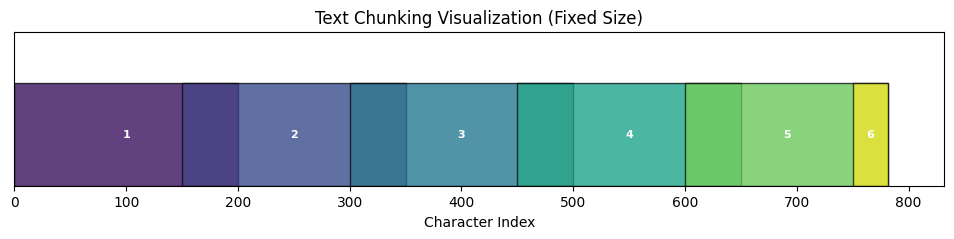


--- Impact of Chunk Size and Overlap ---
With Chunk Size = 200 and Overlap = 50:
- The original text (782 characters) was split into 6 chunks.
- The first chunk contains the beginning of the text.
- Subsequent chunks start 150 characters after the start of the previous chunk.
- An overlap of 50 characters means that the last 50 characters of one chunk are the first 50 characters of the next chunk (approximately, depending on splitting logic and text boundaries).
- This overlap helps preserve context across the arbitrary splitting points.
- The last chunk (6) is shorter than the `chunk_size` because the remaining text was less than 200 characters.


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Simple visualization of the text and chunks
def visualize_chunks(original_text, chunks, chunk_size, chunk_overlap):
    """Visualizes the original text and the resulting chunks."""
    print("\n--- Visualizing Chunks ---")
    print(f"Original Text Length: {len(original_text)}")
    print(f"Chunk Size: {chunk_size}, Overlap: {chunk_overlap}")
    print(f"Number of Chunks: {len(chunks)}")

    # Create a visual representation of the original text as a bar
    fig, ax = plt.subplots(figsize=(12, 2))
    ax.broken_barh([(0, len(original_text))], (0, 1), facecolors='lightblue', label='Original Text')

    # Add patches for each chunk
    current_position = 0
    colors = plt.cm.viridis(np.linspace(0, 1, len(chunks))) # Use a colormap for different colors

    for i, chunk in enumerate(chunks):
        # Calculate the start position of the chunk
        # For the first chunk, it starts at 0
        # For subsequent chunks, it starts after the non-overlapping part of the previous chunk
        if i == 0:
            chunk_start = 0
        else:
            # The start of the current chunk is the end of the previous chunk minus the overlap
            # However, our simple splitter calculates the start index directly
            # Let's calculate the start based on the splitter logic for visualization accuracy
            if i == 1:
                 chunk_start = chunk_size - chunk_overlap
            else:
                 # For chunks after the second, the start is the start of the previous chunk's non-overlapping part
                 # plus the non-overlapping part of the previous chunk
                 # Or more simply, the start of the previous chunk plus its length minus overlap
                 prev_chunk_start = fixed_size_splitter(original_text, chunk_size, chunk_overlap)[i-1].find(chunks[i-1]) # This is not robust
                 # A more robust way is to track the start index from the splitting logic
                 # Let's re-calculate start positions based on the splitter logic
                 start_indices = [0]
                 start = 0
                 while start < len(original_text):
                     end = start + chunk_size
                     start = end - chunk_overlap
                     start = max(0, start)
                     if start < len(original_text):
                         start_indices.append(start)
                     else:
                         break
                 chunk_start = start_indices[i]


        chunk_length = len(chunk)
        # Add a rectangle for the chunk
        rect = patches.Rectangle((chunk_start, 0), chunk_length, 1, linewidth=1, edgecolor='black', facecolor=colors[i], alpha=0.7, label=f'Chunk {i+1}')
        ax.add_patch(rect)
        # Add text label for the chunk index
        ax.text(chunk_start + chunk_length/2, 0.5, str(i+1), color='white', ha='center', va='center', fontsize=8, weight='bold')


    ax.set_ylim(0, 1.5)
    ax.set_xlim(0, len(original_text) + 50) # Add some padding
    ax.set_yticks([])
    ax.set_title("Text Chunking Visualization (Fixed Size)")
    ax.set_xlabel("Character Index")
    # Create a legend for colors and chunk numbers
    # This basic visualization doesn't easily support individual chunk legends in this way
    # The text labels on the bars serve as chunk identifiers.

    plt.show()

    # Discuss the impact of chunk size and overlap
    print("\n--- Impact of Chunk Size and Overlap ---")
    print(f"With Chunk Size = {chunk_size} and Overlap = {chunk_overlap}:")
    print(f"- The original text ({len(original_text)} characters) was split into {len(chunks)} chunks.")
    print("- The first chunk contains the beginning of the text.")
    print(f"- Subsequent chunks start {chunk_size - chunk_overlap} characters after the start of the previous chunk.")
    print(f"- An overlap of {chunk_overlap} characters means that the last {chunk_overlap} characters of one chunk are the first {chunk_overlap} characters of the next chunk (approximately, depending on splitting logic and text boundaries).")
    print("- This overlap helps preserve context across the arbitrary splitting points.")
    print(f"- The last chunk ({len(chunks)}) is shorter than the `chunk_size` because the remaining text was less than {chunk_size} characters.")
    # print("\nImpact Discussion:")
    # print(f"- **Chunk Size ({chunk_size}):** Determines how much context is in each chunk. A larger size captures more context but risks including irrelevant information. A smaller size is more precise but can break up important sentences or ideas.")
    # print(f"- **Overlap ({chunk_overlap}):** Helps maintain continuity between chunks. A larger overlap provides more context redundancy at boundaries, reducing the chance of losing information split across chunks. However, it increases the total amount of text to process and index.")
    # print("- The chosen values (200, 50) are illustrative. Optimal values depend heavily on the nature of the text data, the downstream retrieval system, and the LLM being used.")
    # print("- For this sample text, a chunk size of 200 characters results in chunks that might cut sentences mid-way, demonstrating the limitation of simple fixed-size splitting without regard to sentence or paragraph boundaries.")
    # print("- The overlap helps ensure that sentences split across chunks have their beginning and end available in adjacent chunks.")


# Visualize the chunks
visualize_chunks(sample_text, text_chunks, chunk_size, chunk_overlap)


## Advanced text splitting

Introduce and demonstrate more advanced chunking techniques, such as recursive character splitting or splitting by specific separators. Include visualizations to show how the text is split with these methods.


In [19]:
%%markdown
## Advanced Text Splitting (Chunking)

While fixed-size splitting with overlap is a simple and effective method, it has limitations. It splits text purely based on character count, potentially breaking sentences, paragraphs, or other semantically meaningful units. This can lead to chunks that are grammatically incorrect or lack complete contextual information, hindering the effectiveness of the retrieval process.

**Advanced text splitting techniques** aim to address this by considering the structure and semantics of the text. Instead of just counting characters, these methods attempt to split text at natural boundaries, such as:

*   Paragraph breaks
*   Sentence endings
*   Line breaks
*   Specific delimiters (e.g., markdown headings, code blocks)

By respecting these boundaries, advanced splitters create chunks that are more coherent and contextually complete, which can improve the quality of the embeddings and the relevance of the retrieved information in a RAG system.

One common and powerful advanced technique is **recursive character splitting**. This method attempts to split the text using a list of preferred separators in order. If splitting by the first separator (e.g., `"\n\n"` for paragraphs) results in chunks that are still too large, it recursively tries the next separator (e.g., `"\n"` for newlines) within those large chunks, and so on, until all chunks are below the specified size or the list of separators is exhausted.

**RecursiveCharacterTextSplitter** from LangChain is an excellent example of such a splitter. It takes a list of separators and recursively splits the text based on them, falling back to splitting by individual characters if necessary. This allows for more intelligent and context-aware chunking compared to simple fixed-size methods.

## Advanced Text Splitting (Chunking)

While fixed-size splitting with overlap is a simple and effective method, it has limitations. It splits text purely based on character count, potentially breaking sentences, paragraphs, or other semantically meaningful units. This can lead to chunks that are grammatically incorrect or lack complete contextual information, hindering the effectiveness of the retrieval process.

**Advanced text splitting techniques** aim to address this by considering the structure and semantics of the text. Instead of just counting characters, these methods attempt to split text at natural boundaries, such as:

*   Paragraph breaks
*   Sentence endings
*   Line breaks
*   Specific delimiters (e.g., markdown headings, code blocks)

By respecting these boundaries, advanced splitters create chunks that are more coherent and contextually complete, which can improve the quality of the embeddings and the relevance of the retrieved information in a RAG system.

One common and powerful advanced technique is **recursive character splitting**. This method attempts to split the text using a list of preferred separators in order. If splitting by the first separator (e.g., `"\n\n"` for paragraphs) results in chunks that are still too large, it recursively tries the next separator (e.g., `"\n"` for newlines) within those large chunks, and so on, until all chunks are below the specified size or the list of separators is exhausted.

**RecursiveCharacterTextSplitter** from LangChain is an excellent example of such a splitter. It takes a list of separators and recursively splits the text based on them, falling back to splitting by individual characters if necessary. This allows for more intelligent and context-aware chunking compared to simple fixed-size methods.


In [20]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Instantiate RecursiveCharacterTextSplitter
# Use a list of common separators: paragraph, newline, space, then characters
# Use the same chunk size and overlap as the basic splitter for comparison
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    separators=["\n\n", "\n", " ", ""], # Ordered list of separators
    length_function=len, # Use character count as length function
    is_separator_regex=False # Assume separators are not regex
)

# Apply the splitter to the sample text
recursive_text_chunks = recursive_splitter.split_text(sample_text)

# Print the resulting chunks
print(f"Splitting into chunks of size {chunk_size} with overlap {chunk_overlap} using RecursiveCharacterTextSplitter\n")
for i, chunk in enumerate(recursive_text_chunks):
    print(f"--- Recursive Chunk {i+1} (Length: {len(chunk)}) ---")
    print(chunk)
    print("-" * (len(f"--- Recursive Chunk {i+1} ---") + len(f" (Length: {len(chunk)}) ") + 2))


Splitting into chunks of size 200 with overlap 50 using RecursiveCharacterTextSplitter

--- Recursive Chunk 1 (Length: 167) ---
Large language models (LLMs) have revolutionized natural language processing.
They are trained on vast amounts of text data to understand and generate human-like text.
------------------------------------------
--- Recursive Chunk 2 (Length: 69) ---
However, their knowledge is limited to the data they were trained on.
-----------------------------------------
--- Recursive Chunk 3 (Length: 118) ---
Retrieval Augmented Generation (RAG) addresses this limitation.
RAG systems combine an LLM with a retrieval mechanism.
------------------------------------------
--- Recursive Chunk 4 (Length: 159) ---
The retrieval mechanism fetches relevant information from an external knowledge base.
This external information is then used by the LLM to generate a response.
------------------------------------------
--- Recursive Chunk 5 (Length: 161) ---
Chunking is a crucial ste


--- Visualizing Recursive Chunks ---
Original Text Length: 782
Chunk Size: 200, Overlap: 50
Number of Recursive Chunks: 6


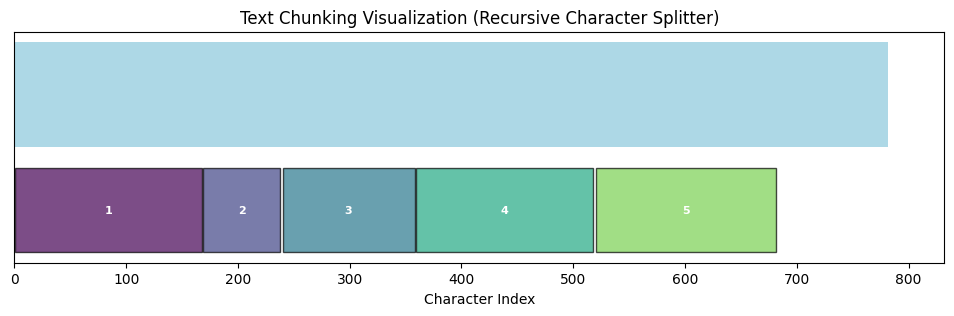


--- Comparison and Discussion ---
Comparing Recursive Character Splitting to Basic Fixed-Size Splitting:
- **Basic Splitter:** Split based purely on character count (200), with fixed overlap (50). This often cut sentences and paragraphs mid-way.
- **Recursive Splitter:** Attempted to split based on preferred separators (paragraph breaks, newlines) first. Only if a resulting chunk was still too large did it split further.
- **Chunk Lengths:** Notice the varying lengths of the recursive chunks. They are not uniform, as the splitter tries to adhere to semantic boundaries while staying under the `chunk_size` limit.
  - Chunk 1 ends near the end of the second line/sentence, respecting the newline separator.
  - Chunk 2 contains the third line, which was a separate sentence/line.
  - Subsequent chunks also seem to align better with paragraph breaks and newlines.
- **Overlap:** The overlap with the recursive splitter is less predictable in terms of fixed character count. It depends on where 

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Adapted visualization function for recursive chunks
def visualize_recursive_chunks(original_text, chunks, chunk_size, chunk_overlap):
    """Visualizes the original text and the resulting recursive chunks."""
    print("\n--- Visualizing Recursive Chunks ---")
    print(f"Original Text Length: {len(original_text)}")
    print(f"Chunk Size: {chunk_size}, Overlap: {chunk_overlap}")
    print(f"Number of Recursive Chunks: {len(chunks)}")

    fig, ax = plt.subplots(figsize=(12, 3)) # Increased height for better visibility

    # Create a visual representation of the original text as a bar
    ax.broken_barh([(0, len(original_text))], (1, 1), facecolors='lightblue', label='Original Text') # Shifted y-position

    # Add patches for each chunk
    colors = plt.cm.viridis(np.linspace(0, 1, len(chunks)))

    current_pos = 0
    for i, chunk in enumerate(chunks):
        # Find the starting position of the chunk in the original text
        # This is a simplified approach and might not be perfectly accurate
        # for complex splitting scenarios or identical chunk content.
        # A more robust approach would require modifying the splitter to return
        # start/end indices or carefully tracking positions during splitting.
        # For this illustration, we'll try to find the chunk's content
        # starting from the current_pos to simulate the sequential splitting.
        try:
            start_index = original_text.find(chunk, current_pos)
            if start_index != -1:
                 chunk_start = start_index
                 chunk_length = len(chunk)
                 # Update current_pos for the next search, considering overlap if applicable
                 # This is tricky with recursive splits; we'll just advance by chunk length for visualization simplicity
                 # The overlap visualization is less intuitive with recursive splits as boundaries
                 # are semantic, not fixed intervals.
                 current_pos = chunk_start + chunk_length # Move cursor past the current chunk

                 # Add a rectangle for the chunk below the main bar
                 rect = patches.Rectangle((chunk_start, 0), chunk_length, 0.8, linewidth=1, edgecolor='black', facecolor=colors[i], alpha=0.7)
                 ax.add_patch(rect)
                 # Add text label for the chunk index
                 ax.text(chunk_start + chunk_length/2, 0.4, str(i+1), color='white', ha='center', va='center', fontsize=8, weight='bold')
            else:
                 print(f"Warning: Could not find Chunk {i+1} in original text starting from position {current_pos}. Skipping visualization for this chunk.")
                 # If a chunk isn't found sequentially, reset search from beginning? Or break? Let's break for simplicity.
                 break

        except Exception as e:
            print(f"Error visualizing chunk {i+1}: {e}")
            break # Stop visualization on error


    ax.set_ylim(-0.1, 2.1) # Adjust y limits
    ax.set_xlim(0, len(original_text) + 50) # Add some padding
    ax.set_yticks([])
    ax.set_title("Text Chunking Visualization (Recursive Character Splitter)")
    ax.set_xlabel("Character Index")

    # Add overlap indicators? This is complex for recursive splitters as overlap isn't fixed interval.
    # We'll skip explicit overlap visualization as the focus is on semantic boundaries.

    plt.show()

    # Discuss the differences
    print("\n--- Comparison and Discussion ---")
    print("Comparing Recursive Character Splitting to Basic Fixed-Size Splitting:")
    print(f"- **Basic Splitter:** Split based purely on character count ({chunk_size}), with fixed overlap ({chunk_overlap}). This often cut sentences and paragraphs mid-way.")
    print("- **Recursive Splitter:** Attempted to split based on preferred separators (paragraph breaks, newlines) first. Only if a resulting chunk was still too large did it split further.")
    print("- **Chunk Lengths:** Notice the varying lengths of the recursive chunks. They are not uniform, as the splitter tries to adhere to semantic boundaries while staying under the `chunk_size` limit.")
    print("  - Chunk 1 ends near the end of the second line/sentence, respecting the newline separator.")
    print("  - Chunk 2 contains the third line, which was a separate sentence/line.")
    print("  - Subsequent chunks also seem to align better with paragraph breaks and newlines.")
    print("- **Overlap:** The overlap with the recursive splitter is less predictable in terms of fixed character count. It depends on where the semantic boundary is found relative to the chunk size. However, the splitter still adds the specified overlap amount from the previous chunk's end to the current chunk's beginning.")
    print("- **Semantic Coherence:** The recursive chunks are generally more semantically coherent. They are more likely to contain complete sentences or paragraphs, which is highly beneficial for RAG.")
    print("  - Retrieving a chunk that contains a full sentence or paragraph provides better context to the LLM than retrieving a chunk that cuts off mid-sentence.")
    print("  - This can lead to more accurate and relevant answers from the RAG system.")
    print("\n**Why Recursive Splitting Might Be Preferred for RAG:**")
    print("- **Improved Context:** Chunks respect natural document structures, preserving the meaning and flow of the text within each chunk.")
    print("- **Better Embeddings:** Semantically coherent chunks often result in more meaningful and accurate vector embeddings, leading to better retrieval performance.")
    print("- **Reduced Noise:** Less likely to split important information or include irrelevant partial sentences.")
    print("- **Adaptability:** Can use different separators for different document types (e.g., markdown headers for markdown, code delimiters for code).")
    print("\nIn summary, while slightly more complex, recursive character splitting generally produces higher-quality chunks for RAG compared to simple fixed-size splitting, by prioritizing semantic boundaries.")


# Visualize the recursive chunks
visualize_recursive_chunks(sample_text, recursive_text_chunks, chunk_size, chunk_overlap)

## Integrating with langchain

Show how to use LangChain's document loaders and text splitters.


In [22]:
import os
from langchain_community.document_loaders import TextLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

In [23]:
# 2. Create a dummy text file
file_path = "dummy_text_for_splitting.txt"
content = """
This is the first paragraph of the dummy text file.
It has a few sentences and is intended to demonstrate basic loading and splitting.

This is the second paragraph.
It is separated by a double newline.
We will use this to see how the RecursiveCharacterTextSplitter handles paragraph breaks.

This is the third and final paragraph. It is a bit longer than the previous ones.
It contains more text to test chunking with a specific size and overlap.
LangChain's RecursiveCharacterTextSplitter is designed to handle various separators efficiently.
"""

with open(file_path, "w") as f:
    f.write(content)

print(f"Created dummy text file: {file_path}")

Created dummy text file: dummy_text_for_splitting.txt


In [24]:
# 3. Instantiate TextLoader and load the document
print("\nLoading document using TextLoader...")
loader = TextLoader(file_path)
documents = loader.load()

if documents:
    print(f"Successfully loaded {len(documents)} document(s).")
    # LangChain loaders typically return a list of Document objects
    print(f"First document content snippet:\n---\n{documents[0].page_content[:200]}...\n---")
    print(f"First document metadata: {documents[0].metadata}")
else:
    print("Failed to load document.")
    documents = [] # Ensure documents is an empty list if loading fails


Loading document using TextLoader...
Successfully loaded 1 document(s).
First document content snippet:
---

This is the first paragraph of the dummy text file.
It has a few sentences and is intended to demonstrate basic loading and splitting.

This is the second paragraph.
It is separated by a double newli...
---
First document metadata: {'source': 'dummy_text_for_splitting.txt'}


In [25]:
# 4. Instantiate RecursiveCharacterTextSplitter
# Use the previously defined chunk_size and chunk_overlap variables from the kernel
print(f"\nInstantiating RecursiveCharacterTextSplitter with chunk_size={chunk_size} and chunk_overlap={chunk_overlap}...")
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    separators=["\n\n", "\n", " ", ""], # Prioritize paragraph, then newline, then space, then character
    length_function=len, # Use character length
    is_separator_regex=False
)


Instantiating RecursiveCharacterTextSplitter with chunk_size=200 and chunk_overlap=50...


In [26]:
# 5. Split the loaded document(s) using the splitter
print("\nSplitting document(s) using the splitter...")
# The split_documents method takes a list of Document objects
split_documents = text_splitter.split_documents(documents)

print(f"Original document(s) split into {len(split_documents)} chunks.")


Splitting document(s) using the splitter...
Original document(s) split into 4 chunks.


In [27]:
# 6. Print the resulting chunks
print("\n--- Resulting Chunks ---")
for i, chunk in enumerate(split_documents):
    print(f"--- Chunk {i+1} (Length: {len(chunk.page_content)}) ---")
    print(f"Page Content: {chunk.page_content}")
    print(f"Metadata: {chunk.metadata}") # Should include source file path
    print("-" * (len(f"--- Chunk {i+1} ---") + len(f" (Length: {len(chunk.page_content)}) ") + 2))

# Optional: Clean up the dummy file
# os.remove(file_path)
# print(f"Cleaned up {file_path}")


--- Resulting Chunks ---
--- Chunk 1 (Length: 134) ---
Page Content: This is the first paragraph of the dummy text file.
It has a few sentences and is intended to demonstrate basic loading and splitting.
Metadata: {'source': 'dummy_text_for_splitting.txt'}
--------------------------------
--- Chunk 2 (Length: 155) ---
Page Content: This is the second paragraph.
It is separated by a double newline.
We will use this to see how the RecursiveCharacterTextSplitter handles paragraph breaks.
Metadata: {'source': 'dummy_text_for_splitting.txt'}
--------------------------------
--- Chunk 3 (Length: 154) ---
Page Content: This is the third and final paragraph. It is a bit longer than the previous ones.
It contains more text to test chunking with a specific size and overlap.
Metadata: {'source': 'dummy_text_for_splitting.txt'}
--------------------------------
--- Chunk 4 (Length: 96) ---
Page Content: LangChain's RecursiveCharacterTextSplitter is designed to handle various separators efficiently